In [63]:

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [64]:
# 2. load csv
url = "https://raw.githubusercontent.com/PeiyaoPearl/CASA0006-Data-Science-for-Spatial-Systems-/refs/heads/main/Assessments/data/Ltds_clean.csv" 
df= pd.read_csv(url)
current_rows = len(df)
print(f"📊 当前加载的记录数: {current_rows}，包含 {len(df.columns)} 个变量。")

# Count the number of records each year
year_counts = df['year'].value_counts().sort_index()

print("📅 各年度行程记录总数：")
print(year_counts)

# 如果你想看占比（百分比）
year_percentage = df['year'].value_counts(normalize=True).sort_index() * 100
print("\n📊 各年度占比 (%)：")
print(year_percentage.round(2))


📊 当前加载的记录数: 220183，包含 18 个变量。
📅 各年度行程记录总数：
year
2014    36327
2015    39066
2016    36663
2017    35375
2018    35626
2019    37126
Name: count, dtype: int64

📊 各年度占比 (%)：
year
2014   16.5000
2015   17.7400
2016   16.6500
2017   16.0700
2018   16.1800
2019   16.8600
Name: proportion, dtype: float64


In [65]:
df.head()


,unique_trip_id,year,mode,distance_(km),journey_purpose,trip_start_time_period,origin_borough,gender,age,car_access,working_status,household_income,disability,ethnicity,household_structure,borough_mean_ptal,borough_pop_density,road_density
0,190010210101,2019,walk,1.0700,shopping and personal business,am peak (0700-0959),barking & dagenham,female,32,no car,not working,10000 - 14999,not disabled,"mixed, other and arab",single pensioner,8.4171,6530.5000,9.5871
1,190010210102,2019,walk,1.0700,shopping and personal business,interpeak (1000-1559),barking & dagenham,female,32,no car,not working,10000 - 14999,not disabled,"mixed, other and arab",single pensioner,8.4171,6530.5000,9.5871
2,190010510301,2019,pt,15.1930,usual workplace,am peak (0700-0959),barking & dagenham,male,35,two or more car,full-time worker,75000 - 99999,not disabled,asian,couple without children,8.4171,6530.5000,9.5871
3,190010510302,2019,pt,15.1930,usual workplace,evening (1900-2159),islington,male,35,two or more car,full-time worker,75000 - 99999,not disabled,asian,couple without children,25.4041,15129.6957,15.9381
4,190010710101,2019,pt,15.9140,education,am peak (0700-0959),barking & dagenham,male,55,one car,part-time worker,5000 - 9999,not disabled,asian,lone parent,8.4171,6530.5000,9.5871


In [66]:
# 查看全表每一列的 NaN 数量
nan_counts = df.isnull().sum()

# 查看全表缺失值占比 (%)
nan_percentage = (df.isnull().sum() / len(df)) * 100

# 专门查看 household_income 列
income_nan = df['household_income'].isnull().sum()

print("--- 缺失值统计 (Total NaN Counts) ---")
print(nan_counts)
print("\n--- 缺失值占比 (Percentage %) ---")
print(nan_percentage)
print(f"\n⚠️ household_income 列共有 {income_nan} 个 NaN 值。")

--- 缺失值统计 (Total NaN Counts) ---
unique_trip_id            0
year                      0
mode                      0
distance_(km)             0
journey_purpose           0
trip_start_time_period    0
origin_borough            0
gender                    0
age                       0
car_access                0
working_status            0
household_income          0
disability                0
ethnicity                 0
household_structure       0
borough_mean_ptal         0
borough_pop_density       0
road_density              0
dtype: int64

--- 缺失值占比 (Percentage %) ---
unique_trip_id           0.0000
year                     0.0000
mode                     0.0000
distance_(km)            0.0000
journey_purpose          0.0000
trip_start_time_period   0.0000
origin_borough           0.0000
gender                   0.0000
age                      0.0000
car_access               0.0000
working_status           0.0000
household_income         0.0000
disability               0.0000
ethn

In [67]:
import pandas as pd
import numpy as np

# 1. 如果该列现在全是 nan，我们需要确保它是字符串类型
# 如果你发现 df['household_income'] 已经彻底丢失数据，请确保之前的加载代码没有 dropna() 掉它
df['household_income'] = df['household_income'].astype(str)

# 2. 定义一个灵活的清洗函数，处理各种符号和空格
def clean_income(val):
    s = str(val).replace('£', '').replace(',', '').strip().lower()
    if 'nan' in s or 'unknown' in s or s == '':
        return 'Unknown'
    
    # 根据关键词映射到你的 10 个分类
    if '100000' in s: return '>100000'
    if '75000' in s: return '75000-99999'
    if '50000' in s: return '50000-74999'
    if '35000' in s: return '35000-49999'
    if '25000' in s: return '25000-34999'
    if '20000' in s: return '20000-24999'
    if '15000' in s: return '15000-19999'
    if '10000' in s: return '10000-14999'
    if '5000' in s: return '5000-9999'
    if 'less than' in s or '0 - 4' in s or 'under' in s: return '<5000'
    
    return 'Unknown'

# 执行清洗映射
df['household_income'] = df['household_income'].apply(clean_income)

# 3. 重新设置为有序分类
income_order_final = ['<5000', '5000-9999', '10000-14999', '15000-19999', 
                      '20000-24999', '25000-34999', '35000-49999', 
                      '50000-74999', '75000-99999', '>100000', 'Unknown']

df['household_income'] = pd.Categorical(df['household_income'], 
                                        categories=income_order_final, 
                                        ordered=True)

# 检查结果：如果这里全是 0，说明原始数据源确实没加载进来
print("清洗后的分布情况：")
print(df['household_income'].value_counts())

清洗后的分布情况：
household_income
50000-74999    35174
>100000        33091
35000-49999    32985
25000-34999    25936
5000-9999      22663
75000-99999    20724
10000-14999    16917
20000-24999    16540
15000-19999    16153
<5000              0
Unknown            0
Name: count, dtype: int64


EDA

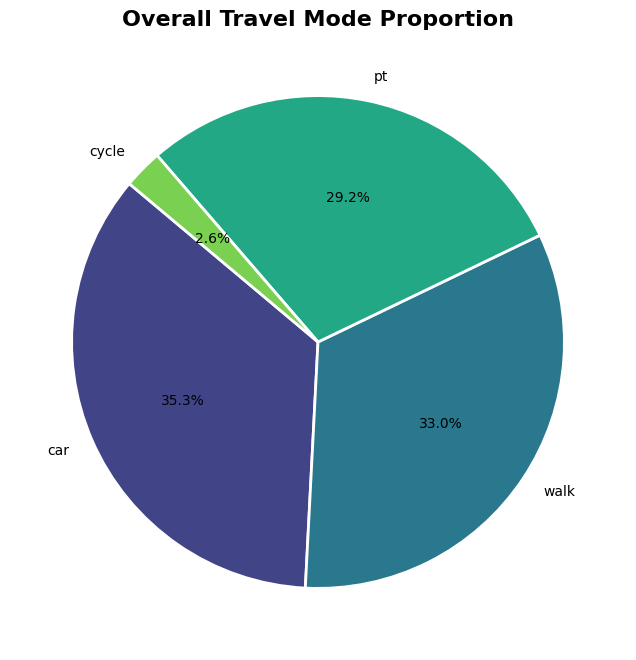

In [68]:
# 1. 独立饼图：出行方式总览
plt.figure(figsize=(8, 8))
mode_counts = df['mode'].value_counts()
plt.pie(mode_counts, labels=mode_counts.index, autopct='%1.1f%%', 
        startangle=140, colors=sns.color_palette("viridis", len(mode_counts)),
        wedgeprops={'edgecolor': 'white', 'linewidth': 2})
plt.title('Overall Travel Mode Proportion', fontsize=16, fontweight='bold')
plt.show()

In [69]:

# Set display resolution
pd.set_option('display.float_format', lambda x: '%.2f' % x)

def generate_academic_table(df):
    results = []

    # --- A. Dependent Variable (mode) ---
    results.append({'Variable': 'Dependent variable', 'Proportion/Mean': '', 'SD': ''})
    counts = df['mode'].value_counts(normalize=True) * 100
    for category, prop in counts.items():
        results.append({'Variable': f'  {category} (%)', 'Proportion/Mean': prop, 'SD': '-'})

    # --- B. Independent Variables (Numerical) ---
    results.append({'Variable': 'Independent variables (Numerical)', 'Proportion/Mean': '', 'SD': ''})
    num_features = {
        'distance_(km)': 'Trip distance (km)',
        'age': 'Age (years)',
        'borough_mean_ptal': 'PTAL Score',
        'road_density': 'Road density (km/km²)'
    }
    
    for col, label in num_features.items():
        if col in df.columns:
            mean_val = df[col].mean()
            sd_val = df[col].std()
            results.append({'Variable': f'  {label}', 'Proportion/Mean': mean_val, 'SD': sd_val})

    # --- C. Independent Variables (Categorical) ---
    cat_features = {
        'gender': 'Gender (%)',
        'household_income': 'Household income (%)',
        'household_structure': 'Household_structure (%)',
        'working_status': 'Employment status (%)'
    }

    for col, label in cat_features.items():
        if col in df.columns:
            results.append({'Variable': label, 'Proportion/Mean': '', 'SD': ''})
            if df[col].isnull().all():
                results.append({'Variable': f'  {col} (Data Missing/NaN)', 'Proportion/Mean': 0, 'SD': ''})
                continue
                
            counts = df[col].value_counts(normalize=True).sort_index() * 100
            for category, prop in counts.items():
                results.append({'Variable': f'  {category}', 'Proportion/Mean': prop, 'SD': ''})

    return pd.DataFrame(results)

final_table = generate_academic_table(df)
print(f"Table 1. Descriptive statistics for variables (N={len(df)})")
display(final_table)

final_table.to_csv('Table_Descriptive_Statistics.csv', index=False, encoding='utf-8-sig')


Table 1. Descriptive statistics for variables (N=220183)


,Variable,Proportion/Mean,SD
0,Dependent variable,,
1,car (%),35.29,-
2,walk (%),32.96,-
3,pt (%),29.19,-
4,cycle (%),2.56,-
5,Independent variables (Numerical),,
6,Trip distance (km),4.96,14.46
7,Age (years),40.07,19.80
8,PTAL Score,14.61,11.80
9,Road density (km/km²),11.08,3.03


/var/folders/2f/9fqrm6p16sxbkj608dl5djbm0000gn/T/ipykernel_93963/1867728489.py:8: Pandas4Warning: Constructing a Categorical with a dtype and values containing non-null entries not in that dtype's categories is deprecated and will raise in a future version.
  df['household_income'] = pd.Categorical(df['household_income'], categories=income_order, ordered=True)
/var/folders/2f/9fqrm6p16sxbkj608dl5djbm0000gn/T/ipykernel_93963/1867728489.py:60: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(title='Mode', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=12)


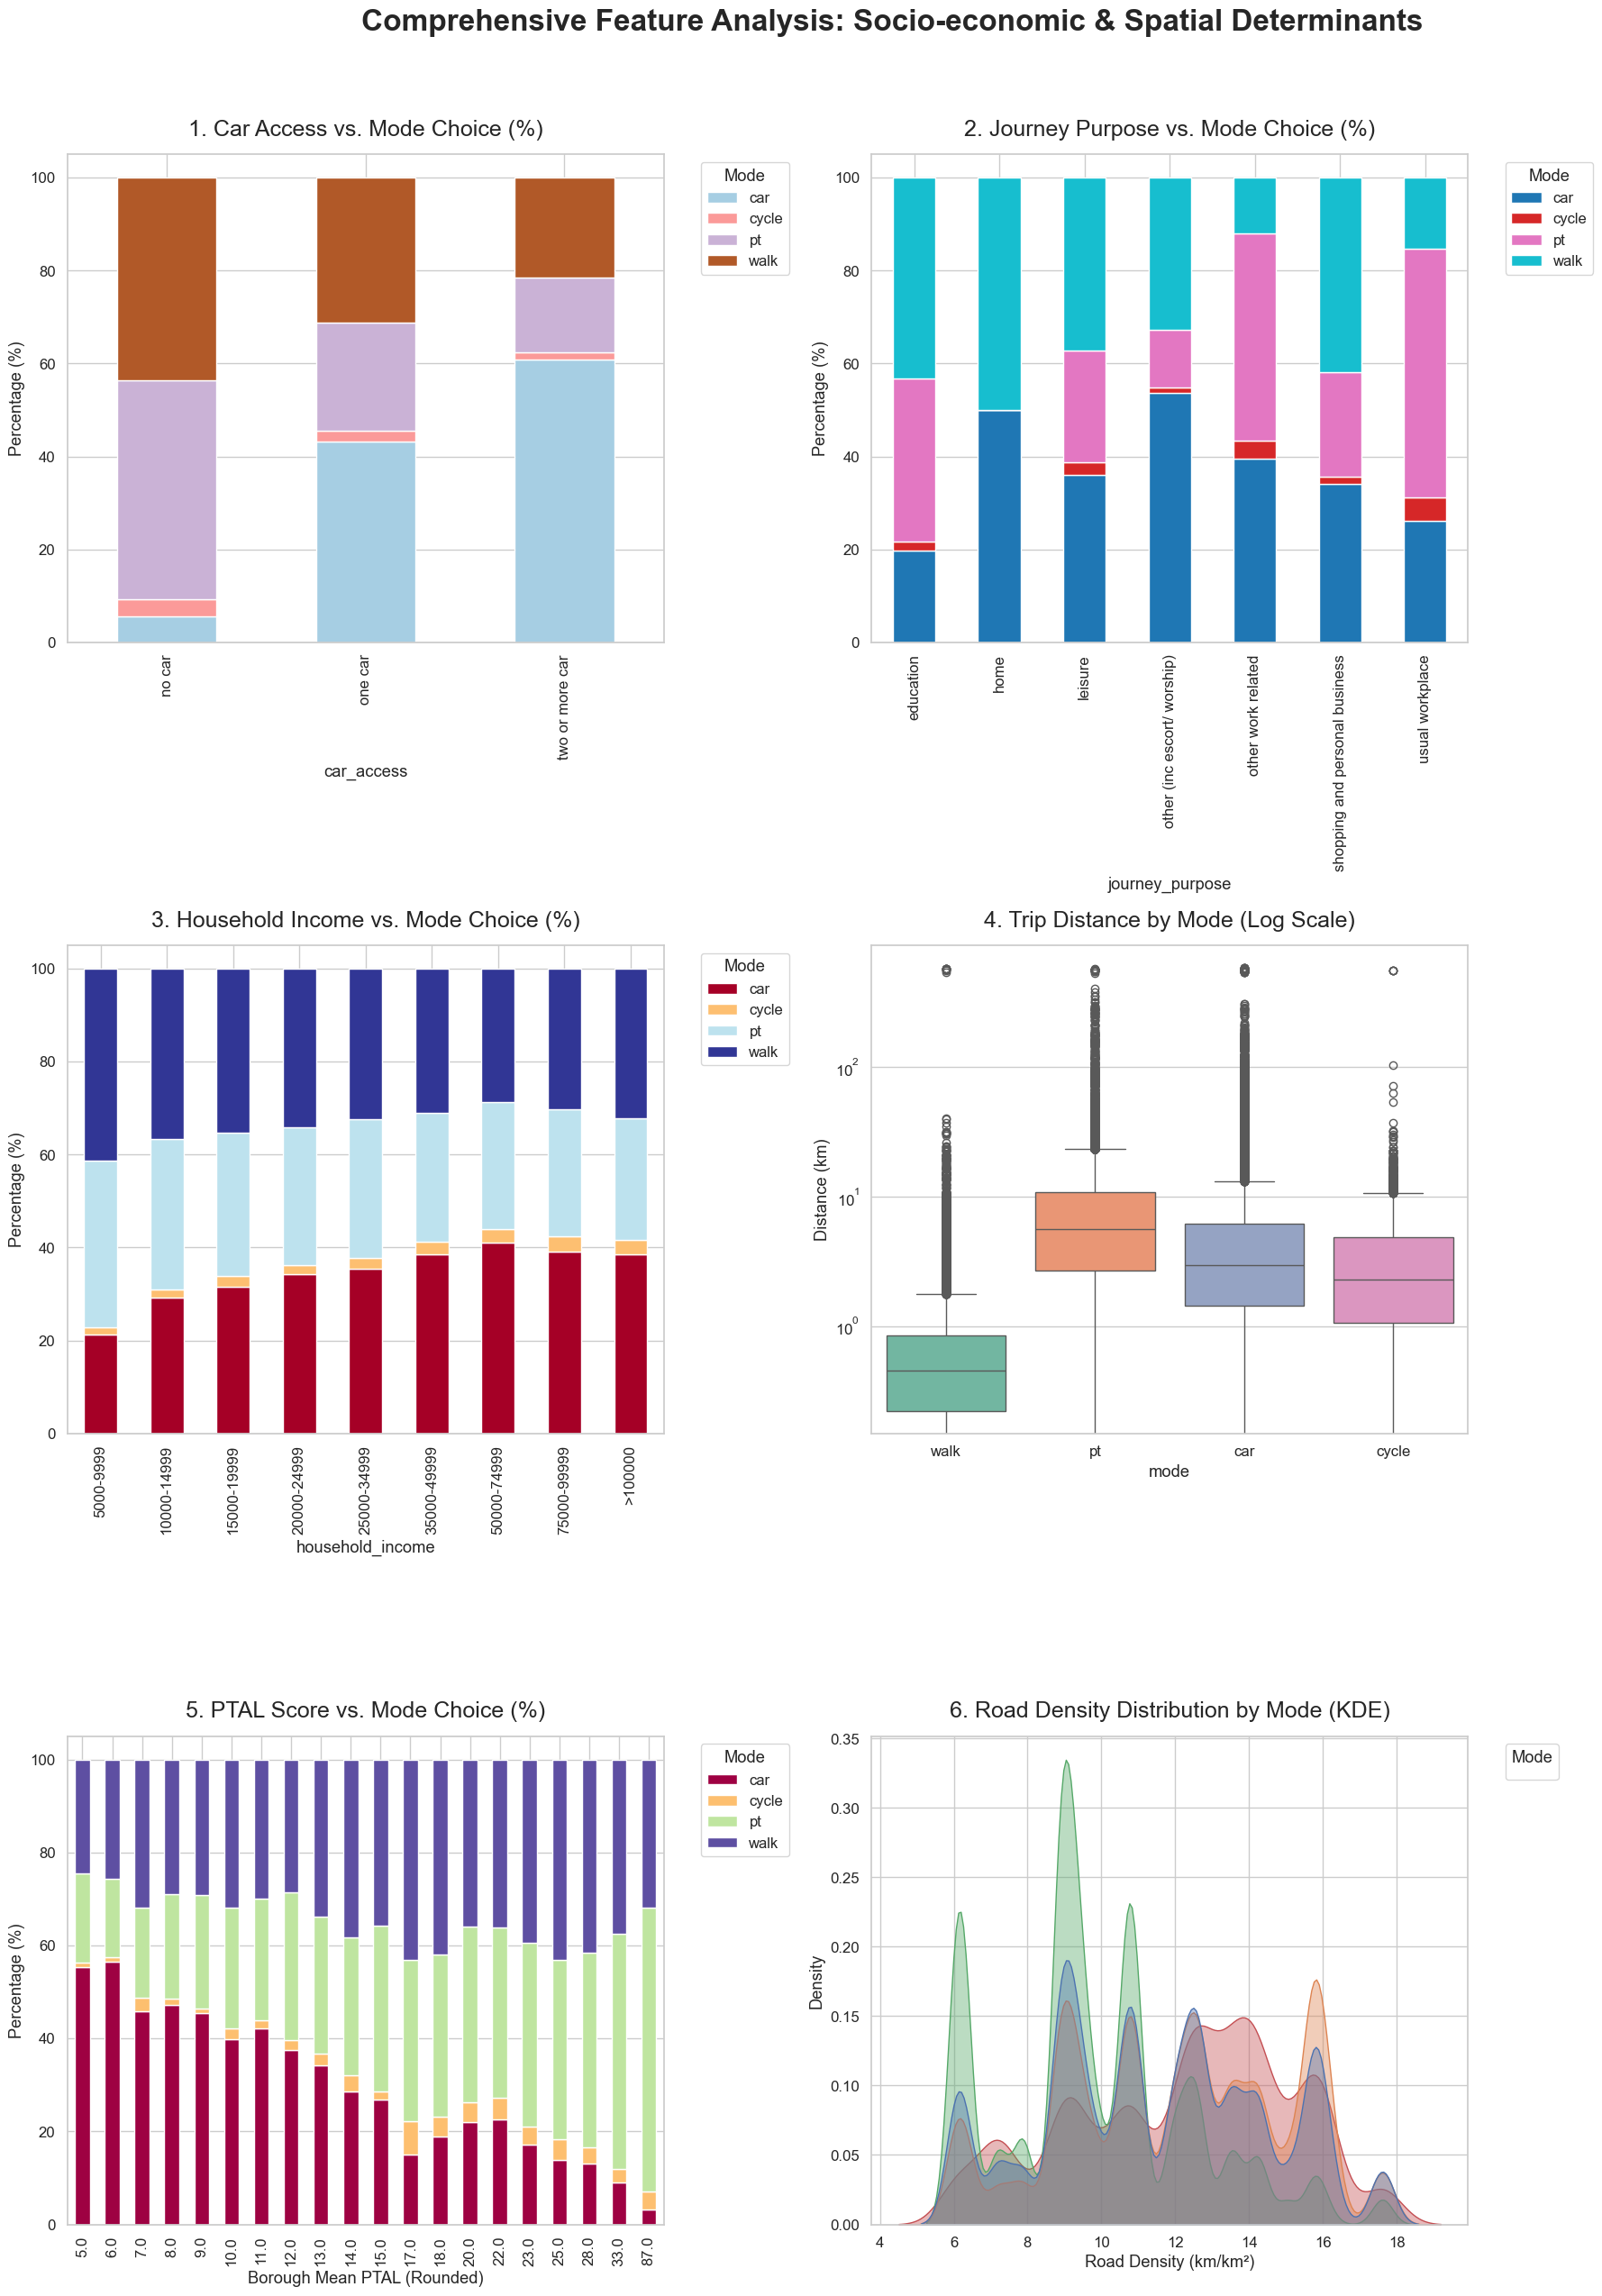

In [70]:
# 1. 风格与基础配置
sns.set_theme(style="whitegrid", font_scale=1.1)
plt.rcParams['font.family'] = 'sans-serif'

# 2. 收入顺序预设 (防止排序混乱)
income_order = ['5000-9999', '10000-14999', '15000-19999', '20000-24999', 
                '25000-34999', '35000-49999', '50000-74999', '75000-99999', '>100000']
df['household_income'] = pd.Categorical(df['household_income'], categories=income_order, ordered=True)

# 3. 创建画布：3行2列
fig, axes = plt.subplots(3, 2, figsize=(20, 26))
fig.suptitle('Comprehensive Feature Analysis: Socio-economic & Spatial Determinants', fontsize=24, fontweight='bold', y=0.98)

# --- 第一行：核心预测因子 ---
# (0,0) Car Access
car_cross = pd.crosstab(df['car_access'], df['mode'], normalize='index') * 100
car_cross.plot(kind='bar', stacked=True, ax=axes[0, 0], colormap='Paired', edgecolor='white')
axes[0, 0].set_title('1. Car Access vs. Mode Choice (%)', fontsize=18, pad=15)
axes[0, 0].set_ylabel('Percentage (%)')

# (0,1) Journey Purpose
purpose_cross = pd.crosstab(df['journey_purpose'], df['mode'], normalize='index') * 100
purpose_cross.plot(kind='bar', stacked=True, ax=axes[0, 1], colormap='tab10', edgecolor='white')
axes[0, 1].set_title('2. Journey Purpose vs. Mode Choice (%)', fontsize=18, pad=15)
axes[0, 1].set_ylabel('Percentage (%)')


# --- 第二行：经济与物理约束 ---
# (1,0) Household Income
income_cross = pd.crosstab(df['household_income'], df['mode'], normalize='index') * 100
income_cross.plot(kind='bar', stacked=True, ax=axes[1, 0], colormap='RdYlBu', edgecolor='white')
axes[1, 0].set_title('3. Household Income vs. Mode Choice (%)', fontsize=18, pad=15)
axes[1, 0].set_ylabel('Percentage (%)')

# (1,1) Trip Distance (Boxplot)
sns.boxplot(data=df, x='mode', y='distance_(km)', ax=axes[1, 1], palette='Set2', hue='mode', legend=False)
axes[1, 1].set_yscale('log')
axes[1, 1].set_title('4. Trip Distance by Mode (Log Scale)', fontsize=18, pad=15)
axes[1, 1].set_ylabel('Distance (km)')


# --- 第三行：建成环境特征 ---
# (2,0) PTAL Score
if 'borough_mean_ptal' in df.columns:
    ptal_cross = pd.crosstab(df['borough_mean_ptal'].round(), df['mode'], normalize='index') * 100
    ptal_cross.plot(kind='bar', stacked=True, ax=axes[2, 0], colormap='Spectral', edgecolor='white')
    axes[2, 0].set_title('5. PTAL Score vs. Mode Choice (%)', fontsize=18, pad=15)
    axes[2, 0].set_xlabel('Borough Mean PTAL (Rounded)')
    axes[2, 0].set_ylabel('Percentage (%)')

# (2,1) Road Density (KDE)
if 'road_density' in df.columns:
    sns.kdeplot(data=df, x='road_density', hue='mode', fill=True, common_norm=False, ax=axes[2, 1], alpha=0.4)
    axes[2, 1].set_title('6. Road Density Distribution by Mode (KDE)', fontsize=18, pad=15)
    axes[2, 1].set_xlabel('Road Density (km/km²)')

# --- 统一调整图例和布局 ---
for ax in axes.flat:
    if ax.get_legend():
        ax.legend(title='Mode', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=12)

plt.tight_layout(rect=[0, 0, 0.9, 0.96])
plt.show()

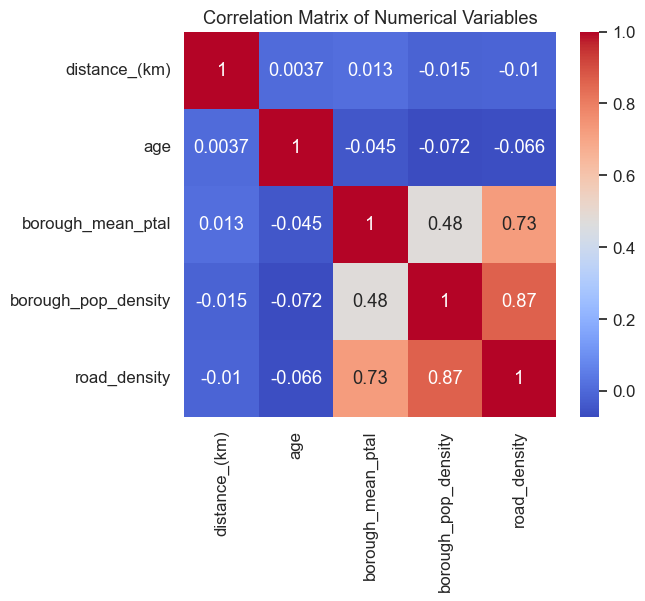

In [71]:
import seaborn as sns
import matplotlib.pyplot as plt

num_cols = ['distance_(km)', 'age', 'borough_mean_ptal', 
            'borough_pop_density', 'road_density']

corr = df[num_cols].corr()

plt.figure(figsize=(6,5))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title('Correlation Matrix of Numerical Variables')
plt.show()

/var/folders/2f/9fqrm6p16sxbkj608dl5djbm0000gn/T/ipykernel_93963/26629734.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()


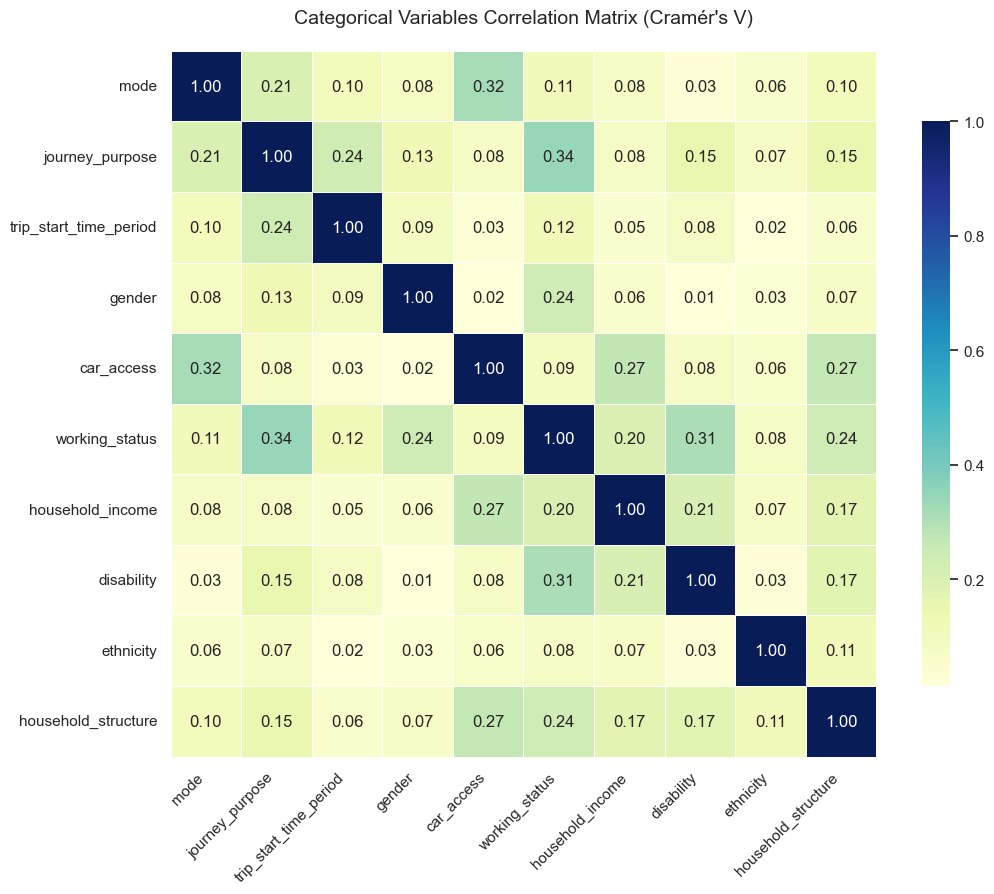

In [102]:
# 1. 筛选变量并排除
cat_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()
if 'origin_borough' in cat_cols:
    cat_cols.remove('origin_borough')

# 2. 计算矩阵 (复用之前的逻辑)
v_matrix = np.zeros((len(cat_cols), len(cat_cols)))
for i in range(len(cat_cols)):
    for j in range(len(cat_cols)):
        v_matrix[i, j] = cramers_v(df[cat_cols[i]], df[cat_cols[j]])
df_v = pd.DataFrame(v_matrix, index=cat_cols, columns=cat_cols)

# 3. 绘图 - 这里更换了配色和风格
plt.figure(figsize=(11, 9))
sns.set_theme(style="white") # 设置白色背景背景

# 使用 'YlGnBu' 配色，并添加了一些细节美化
sns.heatmap(df_v, 
            annot=True, 
            fmt='.2f', 
            cmap='YlGnBu',  # 🔥 在这里更换配色：'YlGnBu', 'rocket_r', 'mako', 'viridis'
            linewidths=.5,  # 格子间的白线，增加精致感
            cbar_kws={"shrink": .8}, # 缩放侧边颜色条
            square=True)    # 强制格子为正方形

plt.title("Categorical Variables Correlation Matrix (Cramér's V)", fontsize=14, pad=20)
plt.xticks(rotation=45, ha='right') # 标签倾斜，防止重叠
plt.tight_layout()
plt.show()

In [72]:
df.head()



,unique_trip_id,year,mode,distance_(km),journey_purpose,trip_start_time_period,origin_borough,gender,age,car_access,working_status,household_income,disability,ethnicity,household_structure,borough_mean_ptal,borough_pop_density,road_density
0,190010210101,2019,walk,1.07,shopping and personal business,am peak (0700-0959),barking & dagenham,female,32,no car,not working,10000-14999,not disabled,"mixed, other and arab",single pensioner,8.42,6530.50,9.59
1,190010210102,2019,walk,1.07,shopping and personal business,interpeak (1000-1559),barking & dagenham,female,32,no car,not working,10000-14999,not disabled,"mixed, other and arab",single pensioner,8.42,6530.50,9.59
2,190010510301,2019,pt,15.19,usual workplace,am peak (0700-0959),barking & dagenham,male,35,two or more car,full-time worker,75000-99999,not disabled,asian,couple without children,8.42,6530.50,9.59
3,190010510302,2019,pt,15.19,usual workplace,evening (1900-2159),islington,male,35,two or more car,full-time worker,75000-99999,not disabled,asian,couple without children,25.40,15129.70,15.94
4,190010710101,2019,pt,15.91,education,am peak (0700-0959),barking & dagenham,male,55,one car,part-time worker,5000-9999,not disabled,asian,lone parent,8.42,6530.50,9.59


第1步：划分数据集 (Data Split - 原 Plan 第三步)
动作：将原始数据切分为 Train (70%), Validation (15%), Test (15%)。
关键点：一定要使用 stratify=y。

In [73]:
!pip install scikit-learn

zsh:1: command not found: pip


In [74]:

from sklearn.model_selection import train_test_split

# 1. 确定特征 (X) 和 标签 (y)
# 我们排除掉无意义的 ID 和 Year，保留你 Plan 中提到的自变量
exclude_cols = ['unique_trip_id', 'year', 'mode', 'origin_borough']
X = df.drop(columns=[col for col in exclude_cols if col in df.columns]) 
y = df['mode']

# 2. 第一次划分：70% 训练集，30% 临时集
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)

# 3. 第二次划分：将 30% 临时集对半分，得到 15% 验证集 和 15% 测试集
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp
)

# --- 验证结果 ---
print(f"数据划分完成：")
print(f"✅ 训练集 (Train): {X_train.shape[0]} 行")
print(f"✅ 验证集 (Val):   {X_val.shape[0]} 行")
print(f"✅ 测试集 (Test):  {X_test.shape[0]} 行")
print(f"\n当前特征列表: {X.columns.tolist()}")

数据划分完成：
✅ 训练集 (Train): 154128 行
✅ 验证集 (Val):   33027 行
✅ 测试集 (Test):  33028 行

当前特征列表: ['distance_(km)', 'journey_purpose', 'trip_start_time_period', 'gender', 'age', 'car_access', 'working_status', 'household_income', 'disability', 'ethnicity', 'household_structure', 'borough_mean_ptal', 'borough_pop_density', 'road_density']


统一平衡源：在 Label Encoding 的数据集上做一次 SMOTE。

派生数据集：

直接用 SMOTE 后的结果跑 RF/XGB。

将 SMOTE 后的特征矩阵进行 One-hot 展开，跑 DNN (Baseline)。

将 SMOTE 后的特征矩阵作为索引输入，跑 DNN (Embedding)。

In [75]:
import sys
!{sys.executable} -m pip install imbalanced-learn


[notice] A new release of pip available: 22.3 -> 26.0.1
[notice] To update, run: pip3 install --upgrade pip


In [76]:
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, StandardScaler
from imblearn.over_sampling import SMOTE
import pandas as pd
import numpy as np
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
# 1. 明确变量分类
cat_features = ['journey_purpose', 'trip_start_time_period', 'gender', 'car_access', 
                'working_status', 'household_income', 'disability', 'ethnicity', 'household_structure']
num_features = ['distance_(km)', 'age', 'borough_mean_ptal', 'borough_pop_density', 'road_density']

# 2. 对原始分类变量进行 Label Encoding (为 SMOTE 做准备)
X_train_le = X_train.copy()
X_val_le = X_val.copy()
X_test_le = X_test.copy()

for col in cat_features:
    le = LabelEncoder()
    # 统一转换，确保验证集和测试集也变成数字索引
    X_train_le[col] = le.fit_transform(X_train[col].astype(str))
    X_val_le[col] = le.transform(X_val[col].astype(str))
    X_test_le[col] = le.transform(X_test[col].astype(str))

# 对目标变量 y 进行编码
le_y = LabelEncoder()
y_train_le = le_y.fit_transform(y_train)
y_val_le = le_y.transform(y_val)
y_test_le = le_y.transform(y_test)

# 3. 核心：在训练集上运行 SMOTE
print("正在执行 SMOTE 平衡训练集...")
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train_le, y_train_le)

# 4. 基于平衡后的水源，生成三路数据集

# --- 【Set A: 树模型 (RF/XGB)】 ---
X_train_set_A = X_train_res
y_train_set_A = y_train_res
# 验证/测试集直接使用之前的 Label 结果
X_val_set_A = X_val_le
X_test_set_A = X_test_le

# --- 【Set B: DNN (One-hot + Scaling)】 ---
scaler = StandardScaler()
# 数值部分标准化
num_train_sc = scaler.fit_transform(X_train_res[num_features])
num_val_sc = scaler.transform(X_val_le[num_features])
num_test_sc = scaler.transform(X_test_le[num_features])

# 分类部分 One-hot (基于 Label 后的数字进行转码)
ohe = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
cat_train_ohe = ohe.fit_transform(X_train_res[cat_features])
cat_val_ohe = ohe.transform(X_val_le[cat_features])
cat_test_ohe = ohe.transform(X_test_le[cat_features])

# 合并数值与分类
X_train_set_B = np.hstack([num_train_sc, cat_train_ohe])
X_val_set_B = np.hstack([num_val_sc, cat_val_ohe])
X_test_set_B = np.hstack([num_test_sc, cat_test_ohe])



print("\n✅ 三路平衡数据集构建完毕！")
print(f"训练集行数 (SMOTE后): {X_train_res.shape[0]}")
print(f"验证集行数 (保持原始): {X_val_le.shape[0]}")
print(f"Set B 特征维度 (One-hot后): {X_train_set_B.shape[1]}")

正在执行 SMOTE 平衡训练集...

✅ 三路平衡数据集构建完毕！
训练集行数 (SMOTE后): 217572
验证集行数 (保持原始): 33027
Set B 特征维度 (One-hot后): 51


 --- 【Set C: DNN (Embedding)】 ---

In [87]:
import numpy as np
from tensorflow.keras.layers import Input, Embedding, Reshape, Concatenate, Dense, Dropout, BatchNormalization
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau


# ==========================================
# 1. 严格阶梯维度逻辑
# ==========================================
def get_ladder_dim(vocab_size):
    # 唯一值数量（不含Mask）
    v = vocab_size - 1
    
    if v <= 3:
        return 1
    elif v <= 6:
        return 3  # 不超过6是3
    elif v <= 10:
        return 6  # 不超过10是6
    else:
        return 10 # 高基数变量（如Age）给10

def build_refined_ladder_model(cat_list, num_list, num_classes):
    all_inputs, all_embeddings = [], []

    # 分类特征嵌入
    for col in cat_list:
        vocab_size = X_train_res[col].nunique() + 1
        emb_dim = get_ladder_dim(vocab_size)
        
        in_layer = Input(shape=(1,), name=f"input_{col}")
        emb_layer = Embedding(vocab_size, emb_dim, name=f"emb_{col}")(in_layer)
        emb_layer = Reshape(target_shape=(emb_dim,))(emb_layer)
        
        all_inputs.append(in_layer)
        all_embeddings.append(emb_layer)
        print(f"Embedding: {col:<22} | Values: {vocab_size-1:<3} | Dim: {emb_dim}")

    # 数值特征直连
    if num_list:
        in_num = Input(shape=(len(num_list),), name="input_numerical")
        all_inputs.append(in_num)
        all_embeddings.append(in_num)
        print(f"Numerical: {num_list} | Dim: {len(num_list)}")

    # 特征融合
    x = Concatenate(name="set_c_concat")(all_embeddings)

    # 深度特征提取
    for _ in range(5):
        x = Dense(256, activation='relu')(x)
        x = BatchNormalization()(x)
        x = Dropout(0.3)(x)

    x = Dense(128, activation='relu')(x)
    x = BatchNormalization()(x)
    x = Dropout(0.3)(x)

    output = Dense(num_classes, activation='softmax')(x)
    return Model(inputs=all_inputs, outputs=output)

# 实例化
final_model = build_refined_ladder_model(cat_to_embed, num_to_keep, len(le_y.classes_))

# 编译
final_model.compile(optimizer=Adam(0.001), loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# 准备数据输入
X_train_inputs = [X_train_res[col].values for col in cat_to_embed] + [num_train_final]
X_val_inputs = [X_val_le[col].values for col in cat_to_embed] + [num_val_final]

# 执行训练
final_model.fit(
    X_train_inputs, y_train_res,
    epochs=100,
    batch_size=2048,
    validation_data=(X_val_inputs, y_val_le),
    callbacks=[
        EarlyStopping(monitor='val_loss', patience=12, restore_best_weights=True),
        ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=4)
    ],
    verbose=1
)

# --- 提取 Set C ---
feature_extractor = Model(inputs=final_model.input, outputs=final_model.get_layer('set_c_concat').output)
X_train_C = feature_extractor.predict(X_train_inputs, batch_size=4096)
X_val_C = feature_extractor.predict(X_val_inputs, batch_size=4096)

print(f"\n✅ 按照 3-6-10 逻辑生成的 Set C 完成！总维度: {X_train_C.shape[1]}")

Embedding: age                    | Values: 95  | Dim: 10
Embedding: journey_purpose        | Values: 7   | Dim: 6
Embedding: trip_start_time_period | Values: 6   | Dim: 3
Embedding: gender                 | Values: 2   | Dim: 1
Embedding: car_access             | Values: 3   | Dim: 1
Embedding: working_status         | Values: 6   | Dim: 3
Embedding: household_income       | Values: 9   | Dim: 6
Embedding: disability             | Values: 2   | Dim: 1
Embedding: ethnicity              | Values: 5   | Dim: 3
Embedding: household_structure    | Values: 6   | Dim: 3
Numerical: ['distance_(km)', 'borough_mean_ptal', 'borough_pop_density', 'road_density'] | Dim: 4
Epoch 1/100
107/107 ━━━━━━━━━━━━━━━━━━━━ 19s 98ms/step - accuracy: 0.4168 - loss: 1.3529 - val_accuracy: 0.5686 - val_loss: 1.1166 - learning_rate: 0.0010
Epoch 2/100
107/107 ━━━━━━━━━━━━━━━━━━━━ 6s 52ms/step - accuracy: 0.5008 - loss: 1.1679 - val_accuracy: 0.5373 - val_loss: 1.4908 - learning_rate: 0.0010
Epoch 3/100
107/107 ━━

random search 优化setc 

In [89]:
def build_c1_extractor_robust(cat_list, num_list, num_classes, units=256, dropout=0.4):
    all_inputs, all_embeddings = [], []

    # 类别特征处理
    for col in cat_list:
        vocab_size = X_train_res[col].nunique() + 1
        emb_dim = get_ladder_dim(vocab_size)
        in_layer = Input(shape=(1,), name=f"input_{col}")
        emb_layer = Embedding(vocab_size, emb_dim, name=f"emb_{col}")(in_layer)
        emb_layer = Reshape(target_shape=(emb_dim,))(emb_layer)
        all_inputs.append(in_layer)
        all_embeddings.append(emb_layer)

    # 数值特征处理
    if num_list:
        in_num = Input(shape=(len(num_list),), name="input_numerical")
        all_inputs.append(in_num)
        all_embeddings.append(in_num)

    # 特征融合点 (Set C)
    x = Concatenate(name="c1_feature_output")(all_embeddings)

    # 使用传入的随机参数 units 和 dropout
    x = Dense(units, activation='relu')(x)
    x = BatchNormalization()(x)
    x = Dropout(dropout)(x)
    
    x = Dense(units // 2, activation='relu')(x) # 第二层通常减半
    x = BatchNormalization()(x)
    x = Dropout(dropout * 0.75)(x)

    output = Dense(num_classes, activation='softmax')(x)
    return Model(inputs=all_inputs, outputs=output)

import random
from tensorflow.keras.callbacks import EarlyStopping

# 1. 定义针对 Embedding 模型的搜索空间
search_space = {
    'lr': [0.003, 0.001, 0.01],
    'units': [256, 512],
    'dr': [0.1, 0.3, 0.5],
    'bs': [256, 512]
}

best_val_acc = 0
best_config = {}

print("🔍 开始为 Set C 生成模型寻找最优参数...")

for i in range(8):  # 尝试 8 组随机组合
    config = {k: random.choice(v) for k, v in search_space.items()}
    print(f"\n尝试组合 {i+1}: {config}")
    
    # 使用你之前的 build_c1_extractor 逻辑，但传入 search 到的参数
    # 这里假设你已经定义了 build_c1_extractor 接受 units 和 dr 参数
    temp_model = build_c1_extractor_robust(
        cat_to_embed, num_to_keep, len(le_y.classes_), 
        units=config['units'], dropout=config['dr']
    )
    
    temp_model.compile(
        optimizer=Adam(learning_rate=config['lr']),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    
    h = temp_model.fit(
        X_train_inputs, y_train_res,
        validation_data=(X_val_inputs, y_val_le),
        epochs=30, # 快速测试，不需要跑满
        batch_size=config['bs'],
        class_weight=class_weight_dict,
        verbose=0,
        callbacks=[EarlyStopping(patience=5, restore_best_weights=True)]
    )
    
    current_val_acc = max(h.history['val_accuracy'])
    print(f"--> 当前验证集 Acc: {current_val_acc:.4f}")
    
    if current_val_acc > best_val_acc:
        best_val_acc = current_val_acc
        best_config = config
        print("✨ 发现更优配置！")

print(f"\n🏆 搜索结束！最佳配置: {best_config}, 最高 Acc: {best_val_acc:.4f}")

🔍 开始为 Set C 生成模型寻找最优参数...

尝试组合 1: {'lr': 0.01, 'units': 256, 'dr': 0.5, 'bs': 256}
--> 当前验证集 Acc: 0.6282
✨ 发现更优配置！

尝试组合 2: {'lr': 0.001, 'units': 512, 'dr': 0.1, 'bs': 512}
--> 当前验证集 Acc: 0.6563
✨ 发现更优配置！

尝试组合 3: {'lr': 0.01, 'units': 256, 'dr': 0.3, 'bs': 512}
--> 当前验证集 Acc: 0.6161

尝试组合 4: {'lr': 0.01, 'units': 256, 'dr': 0.3, 'bs': 512}
--> 当前验证集 Acc: 0.6402

尝试组合 5: {'lr': 0.001, 'units': 256, 'dr': 0.5, 'bs': 512}
--> 当前验证集 Acc: 0.6430

尝试组合 6: {'lr': 0.001, 'units': 512, 'dr': 0.1, 'bs': 256}
--> 当前验证集 Acc: 0.6577
✨ 发现更优配置！

尝试组合 7: {'lr': 0.01, 'units': 256, 'dr': 0.1, 'bs': 256}
--> 当前验证集 Acc: 0.6074

尝试组合 8: {'lr': 0.01, 'units': 256, 'dr': 0.3, 'bs': 256}
--> 当前验证集 Acc: 0.6132

🏆 搜索结束！最佳配置: {'lr': 0.001, 'units': 512, 'dr': 0.1, 'bs': 256}, 最高 Acc: 0.6577


In [93]:
from sklearn.metrics import (accuracy_score, cohen_kappa_score, log_loss, 
                             classification_report, confusion_matrix, roc_curve, auc)
from sklearn.preprocessing import label_binarize
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

def full_evaluate_model(model, X_val, y_val, classes, model_name="Model"):
    # 1. 获取预测结果 - 区分 Keras 和 scikit-learn 模型
    if hasattr(model, 'predict_proba'):
        # scikit-learn 
        y_prob = model.predict_proba(X_val)
        y_pred = model.predict(X_val)
    else:
        # Keras models – `predict()` returns probabilities
        y_prob = model.predict(X_val, verbose=0)
        y_pred = np.argmax(y_prob, axis=1)
    
    # 2. ACC, NLL, CK
    acc = accuracy_score(y_val, y_pred)
    nll = log_loss(y_val, y_prob)
    ck = cohen_kappa_score(y_val, y_pred)
    
    # 3.  G-Mean 
    cm = confusion_matrix(y_val, y_pred)
    recalls = np.diag(cm) / (cm.sum(axis=1) + 1e-9)
    g_mean = np.exp(np.mean(np.log(recalls + 1e-9)))
    
    print(f"\n" + "="*40)
    print(f" {model_name} Final Evaluation Report")
    print("="*40)
    print(f"1. Accuracy (ACC):         {acc:.4f}")
    print(f"2. Neg Log Likelihood (NLL): {nll:.4f}")
    print(f"3. Cohen's Kappa (CK):      {ck:.4f}")
    print(f"4. Geometric Mean (G-Mean):  {g_mean:.4f}")
    
    # 4. Plotting a confusion matrix
    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=classes, yticklabels=classes)
    plt.title(f'Confusion Matrix: {model_name}')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')

    # 5. ROC 
    plt.subplot(1, 2, 2)
    y_val_bin = label_binarize(y_val, classes=range(len(classes)))
    n_classes = len(classes)
    
    for i in range(n_classes):
        fpr, tpr, _ = roc_curve(y_val_bin[:, i], y_prob[:, i])
        roc_auc = auc(fpr, tpr)
        plt.plot(fpr, tpr, label=f'{classes[i]} (AUC = {roc_auc:.2f})')
    
    plt.plot([0, 1], [0, 1], 'k--', alpha=0.5)
    plt.title(f'ROC Curves: {model_name}')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.legend(loc='lower right')
    
    plt.tight_layout()
    plt.show()
    
    return {"ACC": acc, "NLL": nll, "CK": ck, "G-Mean": g_mean}

In [ ]:
随机森林 调参数

SyntaxError: invalid syntax (1723971422.py, line 1)

 Currently searching for the fastest optimal parameters for Set A...
 Currently searching for the fastest optimal parameters for Set B...
 Currently searching for the fastest optimal parameters for Set C...

 Evaluating...

 Set A Final Evaluation Report
1. Accuracy (ACC):         0.8134
2. Neg Log Likelihood (NLL): 0.5364
3. Cohen's Kappa (CK):      0.7267
4. Geometric Mean (G-Mean):  0.6967


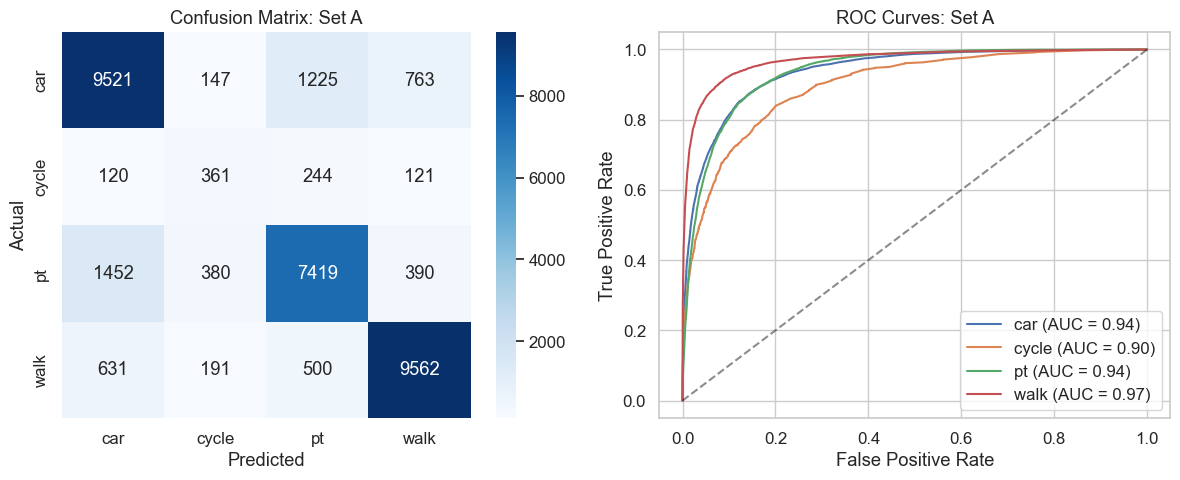


 Set B Final Evaluation Report
1. Accuracy (ACC):         0.8071
2. Neg Log Likelihood (NLL): 0.5411
3. Cohen's Kappa (CK):      0.7179
4. Geometric Mean (G-Mean):  0.6870


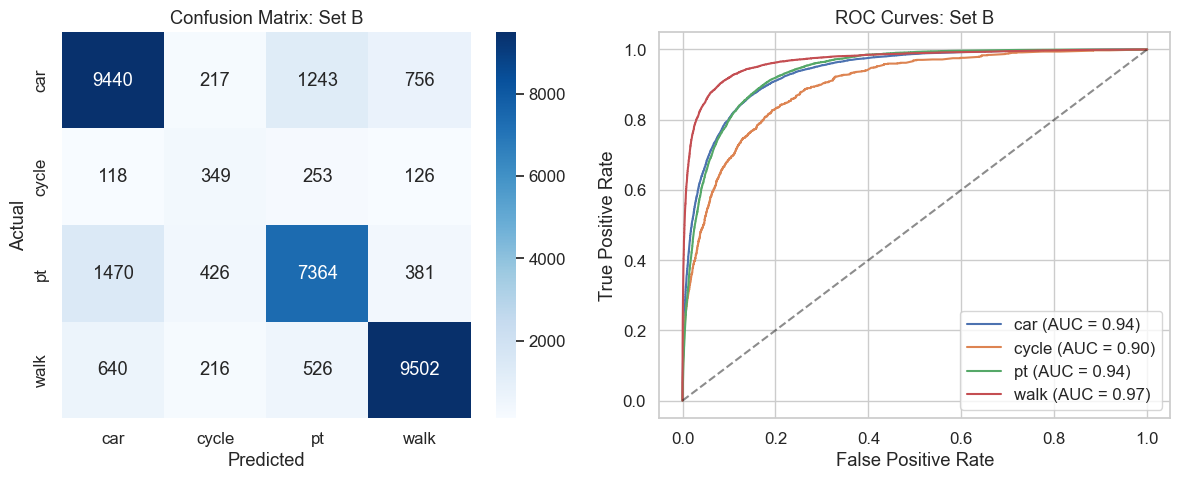


 Set C Final Evaluation Report
1. Accuracy (ACC):         0.8139
2. Neg Log Likelihood (NLL): 0.5409
3. Cohen's Kappa (CK):      0.7281
4. Geometric Mean (G-Mean):  0.7129


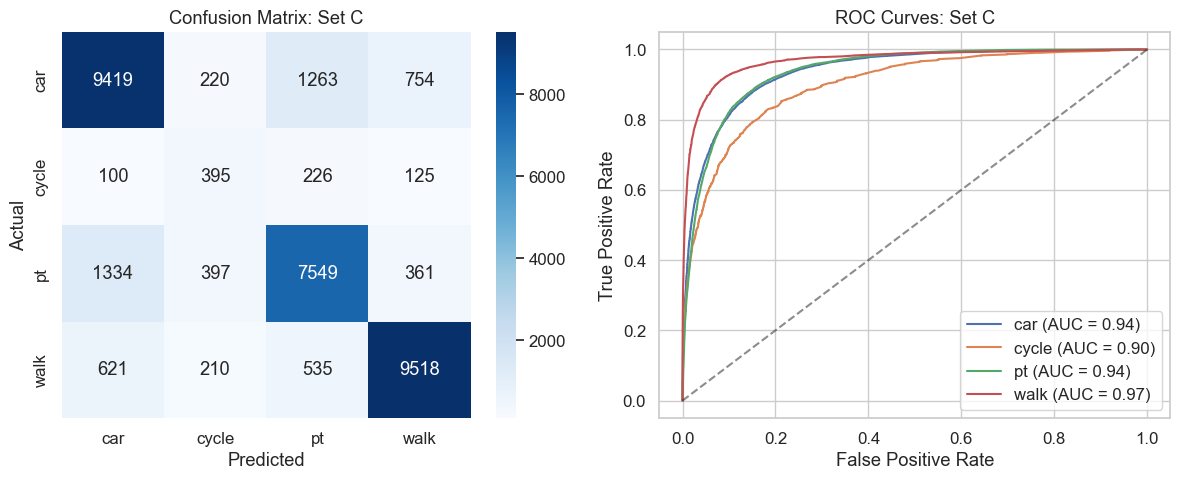


 Ultimate Results:
                  Method  Accuracy    NLL  CK (Kappa)  G-Mean
           Label (Set A)    0.8134 0.5364      0.7267  0.6967
         One-hot (Set B)    0.8071 0.5411      0.7179  0.6870
Entity Embedding (Set C)    0.8139 0.5409      0.7281  0.7129

 Summary of optimal parameters for each group:
Set A: {'n_estimators': 200, 'max_features': 'sqrt', 'max_depth': 30, 'class_weight': None}
Set B: {'n_estimators': 200, 'max_features': 'sqrt', 'max_depth': 30, 'class_weight': None}
Set C: {'n_estimators': 200, 'max_features': 'sqrt', 'max_depth': 30, 'class_weight': None}


In [ ]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier
import pandas as pd

# parameter grid
fast_param_dist = {
    'max_depth': [15, 30],
    'n_estimators': [100, 200],
    'class_weight': [None, 'balanced'],
    'max_features': ['sqrt', 'log2']
}

# --- 1. Set A ---
print(" Currently searching for the fastest optimal parameters for Set A...")
rs_A = RandomizedSearchCV(RandomForestClassifier(random_state=42, n_jobs=-1), 
                          param_distributions=fast_param_dist, n_iter=10, cv=3, scoring='accuracy', random_state=42)
rs_A.fit(X_train_set_A, y_train_res)
best_rf_A = rs_A.best_estimator_

# --- 2. Set B  ---
print(" Currently searching for the fastest optimal parameters for Set B...")
rs_B = RandomizedSearchCV(RandomForestClassifier(random_state=42, n_jobs=-1), 
                          param_distributions=fast_param_dist, n_iter=10, cv=3, scoring='accuracy', random_state=42)
rs_B.fit(X_train_set_B, y_train_res)
best_rf_B = rs_B.best_estimator_

# --- 3. Set C  ---
print(" Currently searching for the fastest optimal parameters for Set C...")
rs_C = RandomizedSearchCV(RandomForestClassifier(random_state=42, n_jobs=-1), 
                          param_distributions=fast_param_dist, n_iter=10, cv=3, scoring='accuracy', random_state=42)
rs_C.fit(X_train_C, y_train_res)
best_rf_C = rs_C.best_estimator_

# --- 4. Evaluation ---
print("\n Evaluating...")
res_A = full_evaluate_model(best_rf_A, X_val_set_A, y_val_le, le_y.classes_, "Set A")
res_B = full_evaluate_model(best_rf_B, X_val_set_B, y_val_le, le_y.classes_, "Set B")
res_C = full_evaluate_model(best_rf_C, X_val_C, y_val_le, le_y.classes_, "Set C")

# -- 5. Creating a comparison table ---
final_comparison = pd.DataFrame({
    'Method': ['Label (Set A)', 'One-hot (Set B)', 'Entity Embedding (Set C)'],
    'Accuracy': [res_A['ACC'], res_B['ACC'], res_C['ACC']],
    'NLL': [res_A['NLL'], res_B['NLL'], res_C['NLL']],
    'CK (Kappa)': [res_A['CK'], res_B['CK'], res_C['CK']],
    'G-Mean': [res_A['G-Mean'], res_B['G-Mean'], res_C['G-Mean']]
})

# Force rounding to 4 decimal places
pd.options.display.float_format = '{:.4f}'.format
print("\n Ultimate Results:")
print(final_comparison.to_string(index=False))

# Summary of optimal parameters for each group
print("\n Summary of optimal parameters for each group:")
print(f"Set A: {rs_A.best_params_}")
print(f"Set B: {rs_B.best_params_}")
print(f"Set C: {rs_C.best_params_}")

XGBoost 

In [ ]:
import sys
print(sys.version)

3.11.0 (v3.11.0:deaf509e8f, Oct 24 2022, 14:43:23) [Clang 13.0.0 (clang-1300.0.29.30)]


In [ ]:
!python3.11 -m pip install xgboost


[notice] A new release of pip available: 22.3 -> 26.0.1
[notice] To update, run: pip3 install --upgrade pip



 The model is currently being optimised: Set A (Label)
Fitting 3 folds for each of 8 candidates, totalling 24 fits
 Set A (Label) The optimal parameters found: {'subsample': 0.9, 'reg_lambda': 10, 'n_estimators': 500, 'max_depth': 10, 'learning_rate': 0.1, 'gamma': 0, 'colsample_bytree': 0.8}

 XGB_Optimized_Set A (Label) Final Evaluation Report
1. Accuracy (ACC):         0.8019
2. Neg Log Likelihood (NLL): 0.5171
3. Cohen's Kappa (CK):      0.7107
4. Geometric Mean (G-Mean):  0.6839


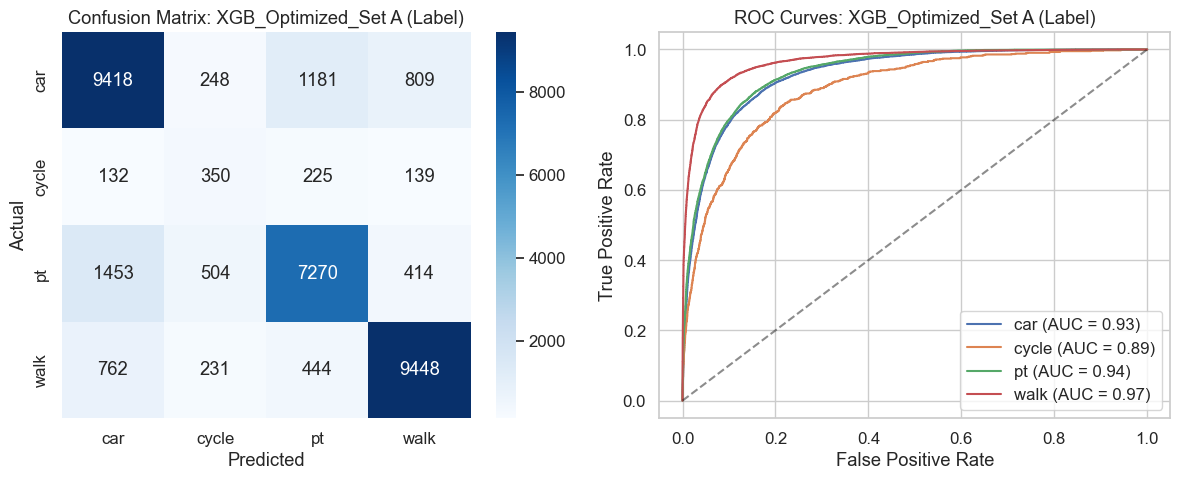


 The model is currently being optimised: Set B (One-hot)
Fitting 3 folds for each of 8 candidates, totalling 24 fits
 Set B (One-hot) The optimal parameters found: {'subsample': 0.9, 'reg_lambda': 10, 'n_estimators': 500, 'max_depth': 10, 'learning_rate': 0.1, 'gamma': 0, 'colsample_bytree': 0.8}

 XGB_Optimized_Set B (One-hot) Final Evaluation Report
1. Accuracy (ACC):         0.7972
2. Neg Log Likelihood (NLL): 0.5231
3. Cohen's Kappa (CK):      0.7042
4. Geometric Mean (G-Mean):  0.6799


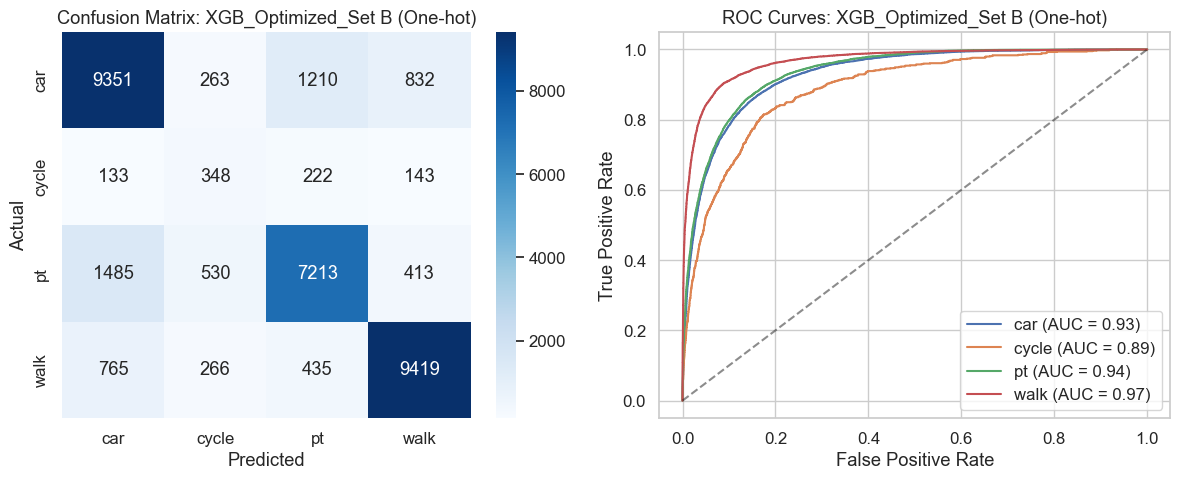


 The model is currently being optimised: Set C (Embedding)
Fitting 3 folds for each of 8 candidates, totalling 24 fits
 Set C (Embedding) The optimal parameters found: {'subsample': 0.9, 'reg_lambda': 10, 'n_estimators': 500, 'max_depth': 10, 'learning_rate': 0.1, 'gamma': 0, 'colsample_bytree': 0.8}

 XGB_Optimized_Set C (Embedding) Final Evaluation Report
1. Accuracy (ACC):         0.7598
2. Neg Log Likelihood (NLL): 0.6071
3. Cohen's Kappa (CK):      0.6521
4. Geometric Mean (G-Mean):  0.6300


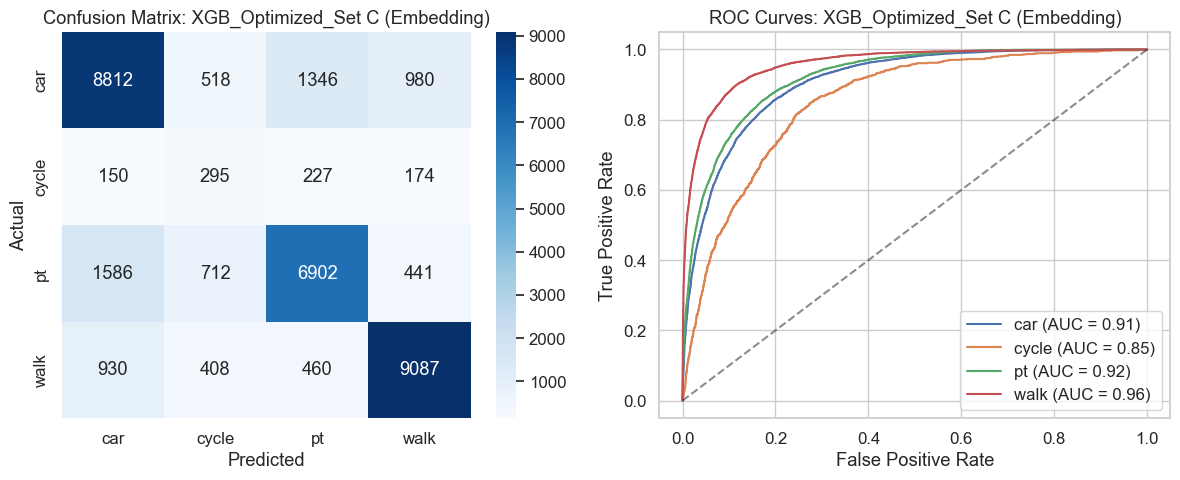


 XGBoost results：
 Method (XGBoost)  Accuracy  G-Mean    NLL  Kappa
    Set A (Label)    0.8019  0.6839 0.5171 0.7107
  Set B (One-hot)    0.7972  0.6799 0.5231 0.7042
Set C (Embedding)    0.7598  0.6300 0.6071 0.6521


In [97]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import confusion_matrix

# 优化后的参数空间：增加正则化项，并允许更浅的树
refined_param_dist = {
    'n_estimators': [300, 500],
    'max_depth': [8, 10],         
    'learning_rate': [0.05, 0.1],
    'subsample': [ 0.8, 0.9],
    'colsample_bytree': [ 0.8, 0.9],
    'reg_lambda': [5, 10],       
    'gamma': [0, 0.1]
}

results_xgb = []

for name, (train_x, val_x, test_x) in xgb_data_map.items():
    print(f"\n" + "="*50)
    print(f" The model is currently being optimised: {name}")
    print("="*50)
    
    # 1. 基础模型定义
    base_xgb = xgb.XGBClassifier(
        objective='multi:softprob',
        num_class=len(le_y.classes_),
        tree_method='hist',
        random_state=42,
        n_jobs=-1
    )
    
    # 2. 随机搜索初始化
    random_search = RandomizedSearchCV(
        base_xgb, 
        param_distributions=refined_param_dist, 
        n_iter=8,  
        cv=3, 
        scoring='accuracy',
        verbose=1,
        random_state=42
    )
    
    # 3. 执行搜索
    # 注意：这里我们不再在 fit 里传 eval_set，因为 cv=3 已经做了内部验证
    random_search.fit(train_x, y_train_res)
    
    # 4. 获取最优模型并手动进行带早停的二次微调（这是最高级的打法）
    best_params = random_search.best_params_
    print(f" {name} The optimal parameters found: {best_params}")
    
    final_clf = xgb.XGBClassifier(**best_params, early_stopping_rounds=30)
    final_clf.fit(
        train_x, y_train_res,
        eval_set=[(val_x, y_val_le)],
        verbose=False
    )
    
    # 5. 调用统一评估函数 (集成 G-Mean, ACC, Kappa, ROC)
    metrics = full_evaluate_model(
        final_clf, 
        test_x, 
        y_test_le, 
        le_y.classes_, 
        model_name=f"XGB_Optimized_{name}"
    )
    
    # 6. 收集结果
    results_xgb.append({
        'Method (XGBoost)': name,
        'Accuracy': metrics['ACC'],
        'G-Mean': metrics['G-Mean'],
        'NLL': metrics['NLL'],
        'Kappa': metrics['CK']
    })

# 展示最终对比表
df_xgb_comparison = pd.DataFrame(results_xgb)
print("\n XGBoost results：")
print(df_xgb_comparison.to_string(index=False))

构建 DNN

In [ ]:
!python3.11 -m pip install tensorflow-macos tensorflow-metal


[notice] A new release of pip available: 22.3 -> 26.0.1
[notice] To update, run: pip3 install --upgrade pip


gpt优化了一遍dnn 用的原始setc

Class weights: {0: 1.0, 1: 1.0, 2: 1.0, 3: 1.0}

 Training DNN on Set A...
Epoch 1/50
425/425 ━━━━━━━━━━━━━━━━━━━━ 28s 37ms/step - accuracy: 0.3322 - loss: 1.4316 - val_accuracy: 0.4501 - val_loss: 1.2864
Epoch 2/50
425/425 ━━━━━━━━━━━━━━━━━━━━ 16s 39ms/step - accuracy: 0.3884 - loss: 1.2932 - val_accuracy: 0.3844 - val_loss: 1.2370
Epoch 3/50
425/425 ━━━━━━━━━━━━━━━━━━━━ 16s 38ms/step - accuracy: 0.4132 - loss: 1.2584 - val_accuracy: 0.4645 - val_loss: 1.2508
Epoch 4/50
425/425 ━━━━━━━━━━━━━━━━━━━━ 17s 39ms/step - accuracy: 0.4200 - loss: 1.2490 - val_accuracy: 0.5168 - val_loss: 1.2094
Epoch 5/50
425/425 ━━━━━━━━━━━━━━━━━━━━ 19s 44ms/step - accuracy: 0.4139 - loss: 1.2545 - val_accuracy: 0.4313 - val_loss: 1.2177
Epoch 6/50
425/425 ━━━━━━━━━━━━━━━━━━━━ 16s 38ms/step - accuracy: 0.4200 - loss: 1.2445 - val_accuracy: 0.5455 - val_loss: 1.1985
Epoch 7/50
425/425 ━━━━━━━━━━━━━━━━━━━━ 15s 36ms/step - accuracy: 0.4274 - loss: 1.2334 - val_accuracy: 0.4300 - val_loss: 1.3734
Epoch 8/50
425/

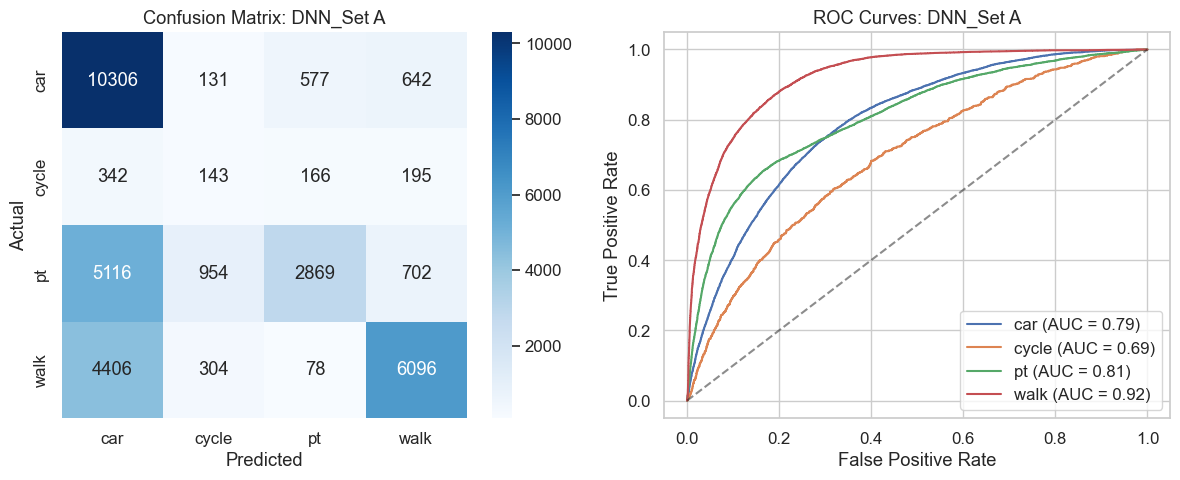


 Training DNN on Set B...
Epoch 1/50
425/425 ━━━━━━━━━━━━━━━━━━━━ 29s 54ms/step - accuracy: 0.5358 - loss: 1.1004 - val_accuracy: 0.6463 - val_loss: 0.9171
Epoch 2/50
425/425 ━━━━━━━━━━━━━━━━━━━━ 15s 35ms/step - accuracy: 0.5818 - loss: 0.9896 - val_accuracy: 0.6293 - val_loss: 0.9380
Epoch 3/50
425/425 ━━━━━━━━━━━━━━━━━━━━ 14s 34ms/step - accuracy: 0.5866 - loss: 0.9805 - val_accuracy: 0.6297 - val_loss: 0.9394
Epoch 4/50
425/425 ━━━━━━━━━━━━━━━━━━━━ 14s 34ms/step - accuracy: 0.5889 - loss: 0.9788 - val_accuracy: 0.6344 - val_loss: 0.9358
Epoch 5/50
425/425 ━━━━━━━━━━━━━━━━━━━━ 14s 34ms/step - accuracy: 0.5852 - loss: 0.9838 - val_accuracy: 0.6299 - val_loss: 0.9429
Epoch 6/50
425/425 ━━━━━━━━━━━━━━━━━━━━ 14s 32ms/step - accuracy: 0.5882 - loss: 0.9778 - val_accuracy: 0.6213 - val_loss: 0.9536
Epoch 7/50
425/425 ━━━━━━━━━━━━━━━━━━━━ 15s 35ms/step - accuracy: 0.5858 - loss: 0.9828 - val_accuracy: 0.6011 - val_loss: 0.9756
Epoch 8/50
425/425 ━━━━━━━━━━━━━━━━━━━━ 15s 35ms/step - accurac

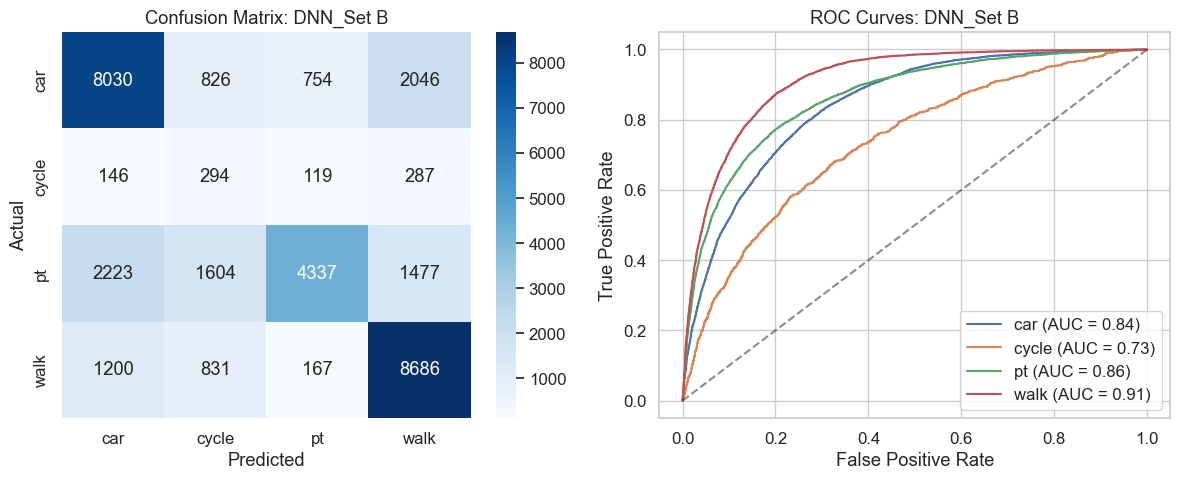


 Training DNN on Set C...
Epoch 1/50
425/425 ━━━━━━━━━━━━━━━━━━━━ 21s 41ms/step - accuracy: 0.5578 - loss: 1.0618 - val_accuracy: 0.6481 - val_loss: 0.9112
Epoch 2/50
425/425 ━━━━━━━━━━━━━━━━━━━━ 16s 37ms/step - accuracy: 0.5905 - loss: 0.9805 - val_accuracy: 0.6378 - val_loss: 0.9192
Epoch 3/50
425/425 ━━━━━━━━━━━━━━━━━━━━ 15s 35ms/step - accuracy: 0.5919 - loss: 0.9733 - val_accuracy: 0.6229 - val_loss: 0.9425
Epoch 4/50
425/425 ━━━━━━━━━━━━━━━━━━━━ 16s 37ms/step - accuracy: 0.5930 - loss: 0.9722 - val_accuracy: 0.6347 - val_loss: 0.9389
Epoch 5/50
425/425 ━━━━━━━━━━━━━━━━━━━━ 16s 37ms/step - accuracy: 0.5923 - loss: 0.9698 - val_accuracy: 0.6369 - val_loss: 0.9356
Epoch 6/50
425/425 ━━━━━━━━━━━━━━━━━━━━ 16s 37ms/step - accuracy: 0.5919 - loss: 0.9725 - val_accuracy: 0.6125 - val_loss: 0.9660
Epoch 7/50
425/425 ━━━━━━━━━━━━━━━━━━━━ 15s 36ms/step - accuracy: 0.5917 - loss: 0.9720 - val_accuracy: 0.6286 - val_loss: 0.9455
Epoch 8/50
425/425 ━━━━━━━━━━━━━━━━━━━━ 15s 36ms/step - accurac

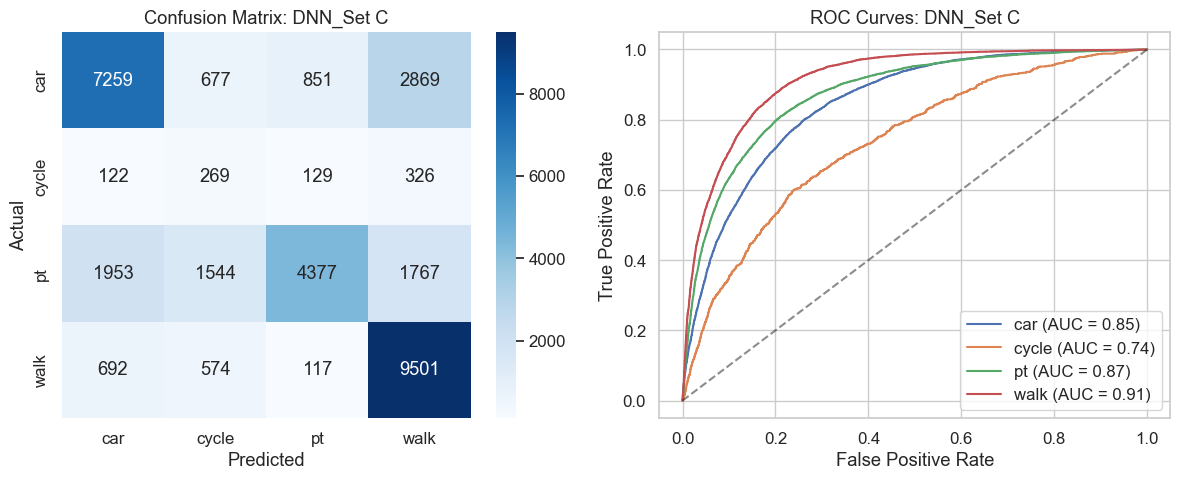


 Final DNN Results:
     Method (DNN)  Accuracy  G-Mean    NLL  CK (Kappa)
    Set A (Label)    0.5878  0.3973 1.0493      0.3889
  Set B (One-hot)    0.6463  0.5415 0.8895      0.4956
Set C (Embedding)    0.6481  0.5293 0.8793      0.4957


In [91]:
import numpy as np
import tensorflow as tf
import pandas as pd
from sklearn.utils.class_weight import compute_class_weight
from tensorflow.keras.layers import Input, Dense, Dropout, BatchNormalization
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

# ==========================================
# 1 DNN 
# ==========================================
def build_simple_dnn(input_dim, num_classes, name):
    inputs = Input(shape=(input_dim,), name=f"input_{name}")
    
    x = Dense(256, activation='relu')(inputs)
    x = BatchNormalization()(x)
    x = Dropout(0.4)(x)
    
    x = Dense(128, activation='relu')(x)
    x = BatchNormalization()(x)
    x = Dropout(0.3)(x)
    
    outputs = Dense(num_classes, activation='softmax')(x)
    
    return Model(inputs=inputs, outputs=outputs, name=f"DNN_{name}")

# ==========================================
# 2 Handling Class Imbalance 
# ==========================================
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train_res),
    y=y_train_res
)
class_weights = dict(enumerate(class_weights))

print("Class weights:", class_weights)

# ==========================================
# 3 A / B / C
# ==========================================
data_map = {
    'Set A': (X_train_set_A, X_val_set_A),
    'Set B': (X_train_set_B, X_val_set_B),
    'Set C': (X_train_C, X_val_C)
}

results_dnn = {}

# ==========================================
# 4 Training
# ==========================================
for set_name, (train_data, val_data) in data_map.items():
    
    print(f"\n Training DNN on {set_name}...")
    
    input_dim = train_data.shape[1]
    
    model = build_simple_dnn(
        input_dim=input_dim,
        num_classes=len(le_y.classes_),
        name=set_name.replace(" ", "_")
    )
    
    model.compile(
        optimizer=Adam(learning_rate=0.001),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    
    # ==========================================
    # 6 Training (Optimised Version)
    # ==========================================
    history = model.fit(
        train_data,
        y_train_res,
        validation_data=(val_data, y_val_le),
        epochs=50,
        batch_size=512,  
        class_weight=class_weights,
        callbacks=[
            EarlyStopping(
                monitor='val_loss',
                patience=12,
                restore_best_weights=True
            )
        ],
        verbose=1
    )
    
    print(f"{set_name} training done. Evaluating...")
    
    # ==========================================
    # 7 evaluate_model
    # ==========================================
    results_dnn[set_name] = full_evaluate_model(
        model,
        val_data,
        y_val_le,
        le_y.classes_,
        f"DNN_{set_name}"
    )

# ==========================================
# 8 results  
# ==========================================
df_dnn_compare = pd.DataFrame({
    'Method (DNN)': [
        'Set A (Label)',
        'Set B (One-hot)',
        'Set C (Embedding)'
    ],
    'Accuracy': [
        results_dnn['Set A']['ACC'],
        results_dnn['Set B']['ACC'],
        results_dnn['Set C']['ACC']
    ],
    'G-Mean': [
        results_dnn['Set A']['G-Mean'], 
        results_dnn['Set B']['G-Mean'],
        results_dnn['Set C']['G-Mean']
    ],
    'NLL': [
        results_dnn['Set A']['NLL'],
        results_dnn['Set B']['NLL'],
        results_dnn['Set C']['NLL']
    ],
    'CK (Kappa)': [
        results_dnn['Set A']['CK'],
        results_dnn['Set B']['CK'],
        results_dnn['Set C']['CK']
    ]
})

pd.options.display.float_format = '{:.4f}'.format

print("\n Final DNN Results:")
print(df_dnn_compare.to_string(index=False))

Table. Results of Different Methods With Different Encoding Techniques
| Model | Embedding | Accuracy | G-Mean | Kappa | NLL |
| :--- | :--- | :---: | :---: | :---: | :---: |
| **Random Forest** | **Set C (Embedding)** | **0.8139** | **0.7129** | **0.7281** | **0.5409** |
| Random Forest | Set A (Label) | 0.8134 | 0.6967 | 0.7267 | 0.5364 |
| Random Forest | Set B (One-hot) | 0.8071 | 0.6870 | 0.7179 | 0.5411 |
| **XGBoost** | **Set A (Label)** | **0.8019** | **0.6839** | **0.7107** | **0.5171** |
| XGBoost | Set B (One-hot) | 0.7972 | 0.6799 | 0.7042 | 0.5231 |
| XGBoost | Set C (Embedding) | 0.7598 | 0.6300 | 0.6521 | 0.6071 |
| **DNN** | **Set C (Embedding)** | **0.6481** | **0.5293** | **0.4957** | **0.8793** |
| DNN | Set B (One-hot) | 0.6463 | 0.5415 | 0.4956 | 0.8895 |
| DNN | Set A (Label) | 0.5878 | 0.3973 | 0.3889 | 1.0493 |